In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully.")

TensorFlow version: 2.20.0
All libraries imported successfully.


In [2]:
df = pd.read_csv("Online Retail.csv")

print("Original dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Original dataset shape: (541909, 8)
Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [3]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    dayfirst=True,
    errors="coerce"
)

clean_df = df.copy()

clean_df = clean_df.drop_duplicates()

clean_df = clean_df.dropna(subset=["Description"])

clean_df = clean_df.dropna(subset=["CustomerID"])

clean_df = clean_df[
    ~clean_df["InvoiceNo"].astype(str).str.startswith("C")
]

clean_df = clean_df[
    clean_df["Quantity"] > 0
]

clean_df = clean_df[
    clean_df["UnitPrice"] > 0
]

clean_df["CustomerID"] = clean_df["CustomerID"].astype(int)

clean_df["TotalAmount"] = (
    clean_df["Quantity"] * clean_df["UnitPrice"]
)

clean_df["Year"] = clean_df["InvoiceDate"].dt.year
clean_df["Month"] = clean_df["InvoiceDate"].dt.month
clean_df["Day"] = clean_df["InvoiceDate"].dt.day
clean_df["Hour"] = clean_df["InvoiceDate"].dt.hour

print("Cleaned dataset shape:", clean_df.shape)
print(
    "Date range:",
    clean_df["InvoiceDate"].min(),
    "to",
    clean_df["InvoiceDate"].max()
)

Cleaned dataset shape: (392692, 13)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [4]:
cutoff_date = pd.Timestamp("2011-09-01")

historical_df = clean_df[
    clean_df["InvoiceDate"] < cutoff_date
].copy()

future_df = clean_df[
    clean_df["InvoiceDate"] >= cutoff_date
].copy()

print("Historical dataset shape:", historical_df.shape)
print("Future dataset shape:", future_df.shape)

print(
    "\nHistorical date range:",
    historical_df["InvoiceDate"].min(),
    "to",
    historical_df["InvoiceDate"].max()
)

print(
    "Future date range:",
    future_df["InvoiceDate"].min(),
    "to",
    future_df["InvoiceDate"].max()
)

Historical dataset shape: (224036, 13)
Future dataset shape: (168656, 13)

Historical date range: 2010-12-01 08:26:00 to 2011-08-31 17:16:00
Future date range: 2011-09-01 08:25:00 to 2011-12-09 12:50:00


In [5]:
historical_customers = set(
    historical_df["CustomerID"].unique()
)

future_customers = set(
    future_df["CustomerID"].unique()
)

target_df = pd.DataFrame({
    "CustomerID": list(historical_customers)
})

target_df["RepeatPurchase"] = (
    target_df["CustomerID"]
    .isin(future_customers)
    .astype(int)
)

print("Target dataset shape:", target_df.shape)

print("\nTarget distribution:")
print(
    target_df["RepeatPurchase"]
    .value_counts()
)

print("\nTarget percentage:")
print(
    target_df["RepeatPurchase"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target dataset shape: (3317, 2)

Target distribution:
RepeatPurchase
1    1952
0    1365
Name: count, dtype: int64

Target percentage:
RepeatPurchase
1    58.85
0    41.15
Name: proportion, dtype: float64


In [6]:
reference_date = (
    historical_df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

customer_features = historical_df.groupby(
    "CustomerID"
).agg(
    Recency=(
        "InvoiceDate",
        lambda x: (reference_date - x.max()).days
    ),
    Frequency=(
        "InvoiceNo",
        "nunique"
    ),
    Monetary=(
        "TotalAmount",
        "sum"
    ),
    TotalQuantity=(
        "Quantity",
        "sum"
    ),
    UniqueProducts=(
        "StockCode",
        "nunique"
    )
).reset_index()

customer_features["AvgOrderValue"] = (
    customer_features["Monetary"]
    / customer_features["Frequency"]
)

print(
    "Customer feature shape:",
    customer_features.shape
)

print("\nCustomer features:")
print(customer_features.head())

Customer feature shape: (3317, 7)

Customer features:
   CustomerID  Recency  Frequency  Monetary  TotalQuantity  UniqueProducts  \
0       12346      226          1  77183.60          74215               1   
1       12347       30          5   2790.86           1590              82   
2       12348      149          3   1487.24           2124              22   
3       12350      211          1    334.40            197              17   
4       12352      163          5   1561.81            254              26   

   AvgOrderValue  
0   77183.600000  
1     558.172000  
2     495.746667  
3     334.400000  
4     312.362000  


In [7]:
model_df = customer_features.merge(
    target_df,
    on="CustomerID",
    how="inner"
)

print("Final modeling dataset shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nMissing values:")
print(model_df.isnull().sum())

Final modeling dataset shape: (3317, 8)

Columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'UniqueProducts', 'AvgOrderValue', 'RepeatPurchase']

Missing values:
CustomerID        0
Recency           0
Frequency         0
Monetary          0
TotalQuantity     0
UniqueProducts    0
AvgOrderValue     0
RepeatPurchase    0
dtype: int64


In [8]:
feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "UniqueProducts",
    "AvgOrderValue"
]

X = model_df[feature_columns].copy()
y = model_df["RepeatPurchase"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(feature_columns)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (3317, 6)
Target shape: (3317,)

Features:
['Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'UniqueProducts', 'AvgOrderValue']

Target distribution:
RepeatPurchase
1    1952
0    1365
Name: count, dtype: int64


In [9]:
X_log = np.log1p(X)

print("Log transformation completed.")

print("\nOriginal feature statistics:")
print(X.describe().round(2))

print("\nLog-transformed feature statistics:")
print(X_log.describe().round(2))

Log transformation completed.

Original feature statistics:
       Recency  Frequency   Monetary  TotalQuantity  UniqueProducts  \
count  3317.00    3317.00    3317.00        3317.00         3317.00   
mean     93.11       3.44    1575.97         923.76           49.09   
std      76.68       5.59    5974.01        3733.91           66.19   
min       1.00       1.00       2.90           1.00            1.00   
25%      28.00       1.00     258.25         128.00           13.00   
50%      73.00       2.00     552.80         305.00           29.00   
75%     146.00       4.00    1355.11         767.00           62.00   
max     274.00     127.00  176355.94      126731.00         1190.00   

       AvgOrderValue  
count        3317.00  
mean          399.43  
std          1435.70  
min             2.90  
25%           168.20  
50%           283.50  
75%           412.65  
max         77183.60  

Log-transformed feature statistics:
       Recency  Frequency  Monetary  TotalQuantity  Uniq

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_log,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (2653, 6)
Testing set shape: (664, 6)

Training target distribution:
RepeatPurchase
1    1561
0    1092
Name: count, dtype: int64

Testing target distribution:
RepeatPurchase
1    391
0    273
Name: count, dtype: int64


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Processed training shape:", X_train_scaled.shape)
print("Processed testing shape:", X_test_scaled.shape)

print("\nProcessed training mean:")
print(np.round(X_train_scaled.mean(axis=0), 4))

print("\nProcessed training standard deviation:")
print(np.round(X_train_scaled.std(axis=0), 4))

Processed training shape: (2653, 6)
Processed testing shape: (664, 6)

Processed training mean:
[ 0.  0. -0. -0.  0.  0.]

Processed training standard deviation:
[1. 1. 1. 1. 1. 1.]


In [12]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Final training shape:", X_train_final.shape)
print("Validation shape:", X_val.shape)
print("Testing shape:", X_test_scaled.shape)

print("\nFinal training target distribution:")
print(y_train_final.value_counts())

print("\nValidation target distribution:")
print(y_val.value_counts())

Final training shape: (2122, 6)
Validation shape: (531, 6)
Testing shape: (664, 6)

Final training target distribution:
RepeatPurchase
1    1249
0     873
Name: count, dtype: int64

Validation target distribution:
RepeatPurchase
1    312
0    219
Name: count, dtype: int64


In [13]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(6,)),
    Dropout(0.30),

    Dense(64, activation="relu"),
    Dropout(0.20),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,265 (44.00 KB)

 Trainable params: 11,265 (44.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [15]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

print("Early stopping configured.")

Early stopping configured.


In [16]:
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6711 - auc: 0.7311 - loss: 0.5903 - precision: 0.7108 - recall: 0.7438 - val_accuracy: 0.6365 - val_auc: 0.7097 - val_loss: 0.6055 - val_precision: 0.7576 - val_recall: 0.5609
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6866 - auc: 0.7460 - loss: 0.5747 - precision: 0.7689 - recall: 0.6685 - val_accuracy: 0.6441 - val_auc: 0.7125 - val_loss: 0.5990 - val_precision: 0.7431 - val_recall: 0.6026
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6942 - auc: 0.7541 - loss: 0.5697 - precision: 0.7674 - recall: 0.6894 - val_accuracy: 0.6535 - val_auc: 0.7125 - val_loss: 0.6007 - val_precision: 0.7481 - val_recall: 0.6186
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7003 - auc: 0.7558 - loss: 0.5684 - precision: 0.7700 - recall: 0.6998 - val_accuracy: 0.6460 - val_auc: 0.7163 - val_loss: 0.6000 - val_precision: 0.7480 - val_recall: 0.5994
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━

In [17]:
print("Training completed.")

print(
    "Total epochs trained:",
    len(history.history["loss"])
)

best_epoch = (
    np.argmin(history.history["val_loss"]) + 1
)

print(
    "Best epoch based on validation loss:",
    best_epoch
)

print(
    "Best validation loss:",
    min(history.history["val_loss"])
)

Training completed.
Total epochs trained: 23
Best epoch based on validation loss: 13
Best validation loss: 0.5921701192855835


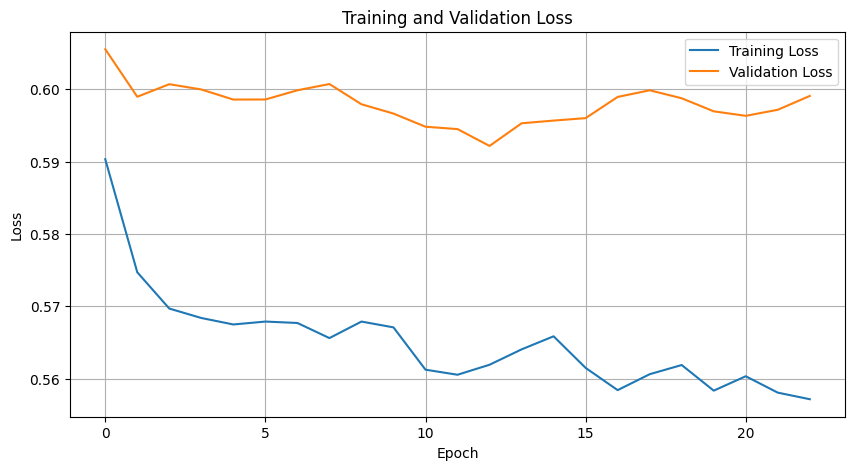

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

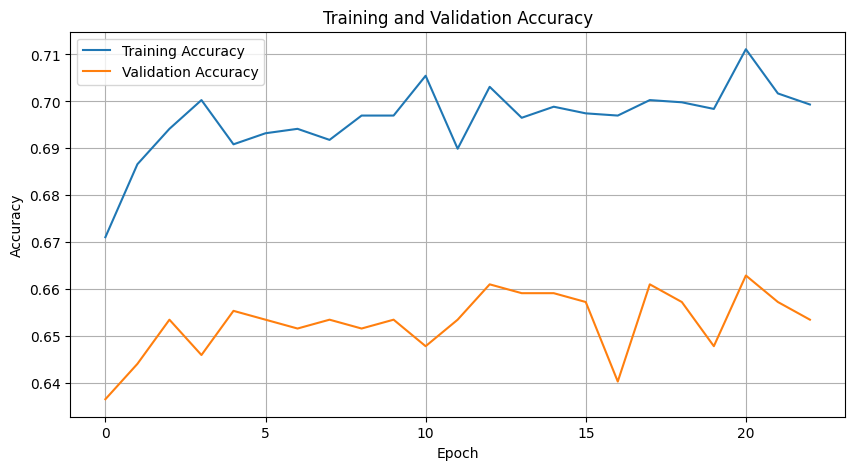

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

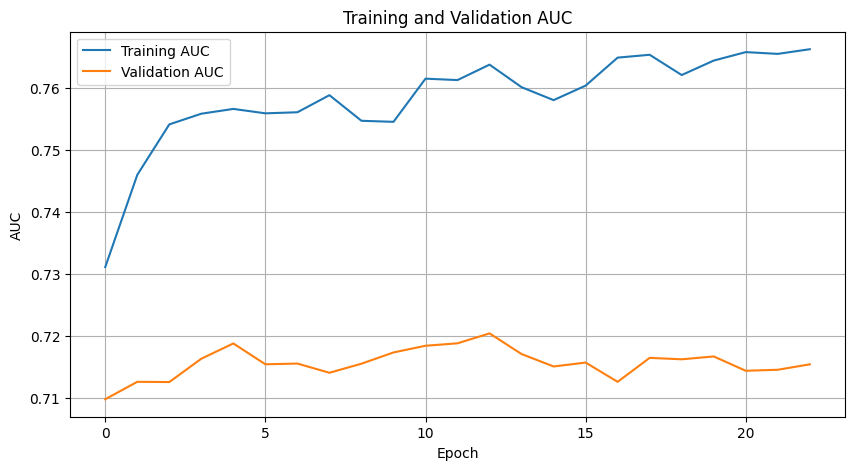

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["auc"], label="Training AUC")
plt.plot(history.history["val_auc"], label="Validation AUC")

plt.title("Training and Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Evaluate ANN on the unseen test set

test_results = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_results[0])
print("Test Accuracy:", test_results[1])
print("Test Precision:", test_results[2])
print("Test Recall:", test_results[3])
print("Test AUC:", test_results[4])

Test Loss: 0.5798140168190002
Test Accuracy: 0.6822289228439331
Test Precision: 0.7393617033958435
Test Recall: 0.710997462272644
Test AUC: 0.7401562929153442


In [22]:
# Generate predictions

y_test_prob = model.predict(X_test_scaled).ravel()
y_test_pred = (y_test_prob >= 0.5).astype(int)

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Accuracy :", round(test_accuracy, 4))
print("Precision:", round(test_precision, 4))
print("Recall   :", round(test_recall, 4))
print("F1-Score :", round(test_f1, 4))
print("ROC-AUC  :", round(test_roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Accuracy : 0.6822
Precision: 0.7394
Recall   : 0.711
F1-Score : 0.7249
ROC-AUC  : 0.7401

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.64      0.62       273
           1       0.74      0.71      0.72       391

    accuracy                           0.68       664
   macro avg       0.67      0.68      0.67       664
weighted avg       0.69      0.68      0.68       664



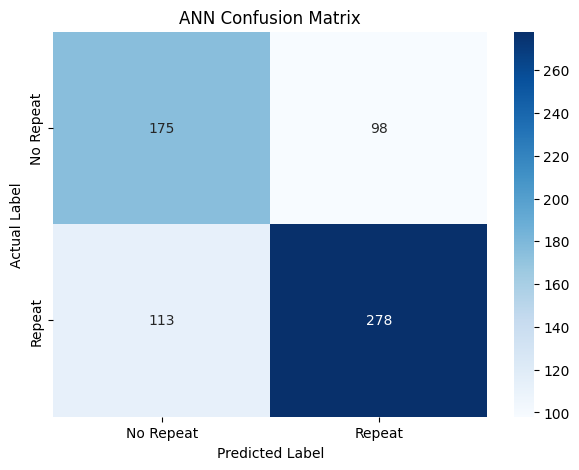

In [23]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Repeat", "Repeat"],
    yticklabels=["No Repeat", "Repeat"]
)

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

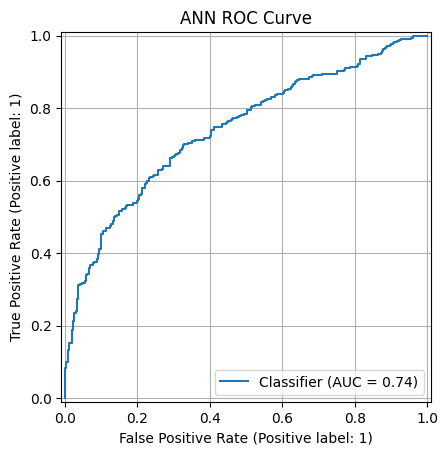

In [24]:
RocCurveDisplay.from_predictions(
    y_test,
    y_test_prob
)

plt.title("ANN ROC Curve")
plt.grid(True)
plt.show()

In [25]:
# Task 4 vs Task 5 model comparison

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Artificial Neural Network"
    ],
    "Accuracy": [
        0.6852,
        0.6386,
        test_accuracy
    ],
    "Precision": [
        0.7395,
        0.6931,
        test_precision
    ],
    "Recall": [
        0.7187,
        0.6931,
        test_recall
    ],
    "F1-Score": [
        0.7289,
        0.6931,
        test_f1
    ],
    "ROC-AUC": [
        0.7344,
        0.7001,
        test_roc_auc
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.685200,0.739500,0.718700,0.728900,0.734400
1,Random Forest,0.638600,0.693100,0.693100,0.693100,0.700100
2,Artificial Neural Network,0.682229,0.739362,0.710997,0.724902,0.740095


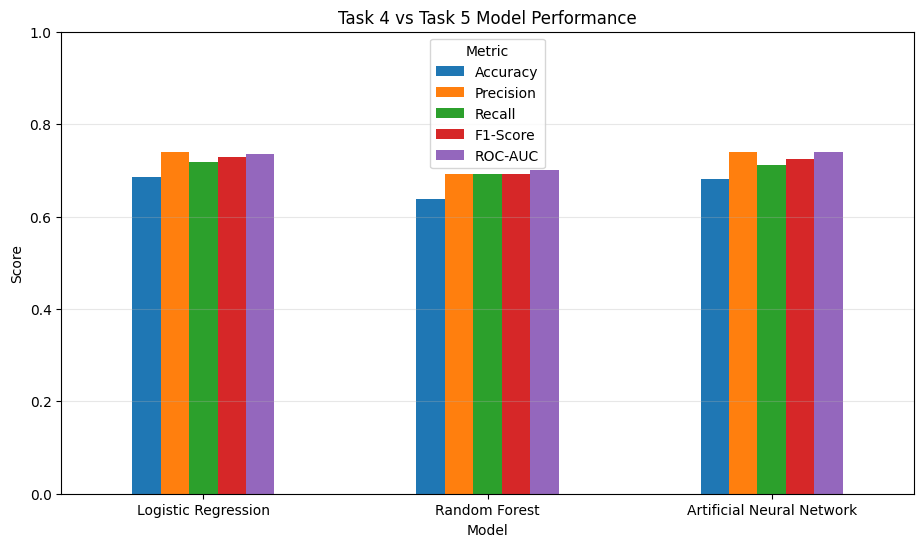

In [26]:
comparison_plot = comparison_df.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Task 4 vs Task 5 Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [27]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="task5_ann_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    show_dtype=False,
    dpi=150
)

print("Architecture diagram saved as task5_ann_architecture.png")

Architecture diagram saved as task5_ann_architecture.png


In [28]:
model.save("task5_customer_repeat_purchase_ann.keras")

print("Model saved successfully.")

Model saved successfully.


In [29]:
predictions_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred,
    "Probability": y_test_prob
})

predictions_df.to_csv(
    "task5_ann_predictions.csv",
    index=False
)

print("Predictions saved successfully.")
print("Prediction file shape:", predictions_df.shape)

Predictions saved successfully.
Prediction file shape: (664, 3)


In [30]:
from google.colab import files

files.download("task5_customer_repeat_purchase_ann.keras")
files.download("task5_ann_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
from google.colab import files

files.download("task5_ann_architecture.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>